<a href="https://colab.research.google.com/github/HariPriyagumpu/Customer-Spending-Analysis/blob/main/Customer_Spending_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/sales_data.csv',encoding='latin1')
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [ ]:
df["Amount"].isnull()

,Amount
0,False
1,False
2,False
3,False
4,False
...,...
11246,False
11247,False
11248,False
11249,False


In [ ]:
df.drop(["Status","unnamed1"], axis=1, inplace=True)

In [ ]:
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0


In [ ]:
df=df.dropna()
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0


In [ ]:
df.rename(columns={'Marital_Status':'Marital'})

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0


In [ ]:
df = df.rename(columns={'Marital_Status':'Marital'})
df["Marital"] = df["Marital"].replace({0: "Single",1: "Married"})
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,Married,Maharashtra,Western,Chemical,Office,4,370.0
11247,1004089,Reichenbach,P00171342,M,26-35,33,Single,Haryana,Northern,Healthcare,Veterinary,3,367.0
11248,1001209,Oshin,P00201342,F,36-45,40,Single,Madhya Pradesh,Central,Textile,Office,4,213.0
11249,1004023,Noonan,P00059442,M,36-45,37,Single,Karnataka,Southern,Agriculture,Office,3,206.0


In [ ]:
df["Gender"] = df["Gender"].replace({'F':'Female','M':'Male'})
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,Female,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,Female,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,Female,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,Male,0-17,16,Single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,Male,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,Male,18-25,19,Married,Maharashtra,Western,Chemical,Office,4,370.0
11247,1004089,Reichenbach,P00171342,Male,26-35,33,Single,Haryana,Northern,Healthcare,Veterinary,3,367.0
11248,1001209,Oshin,P00201342,Female,36-45,40,Single,Madhya Pradesh,Central,Textile,Office,4,213.0
11249,1004023,Noonan,P00059442,Male,36-45,37,Single,Karnataka,Southern,Agriculture,Office,3,206.0


In [ ]:
df.isnull().sum()

,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital,0
State,0
Zone,0
Occupation,0


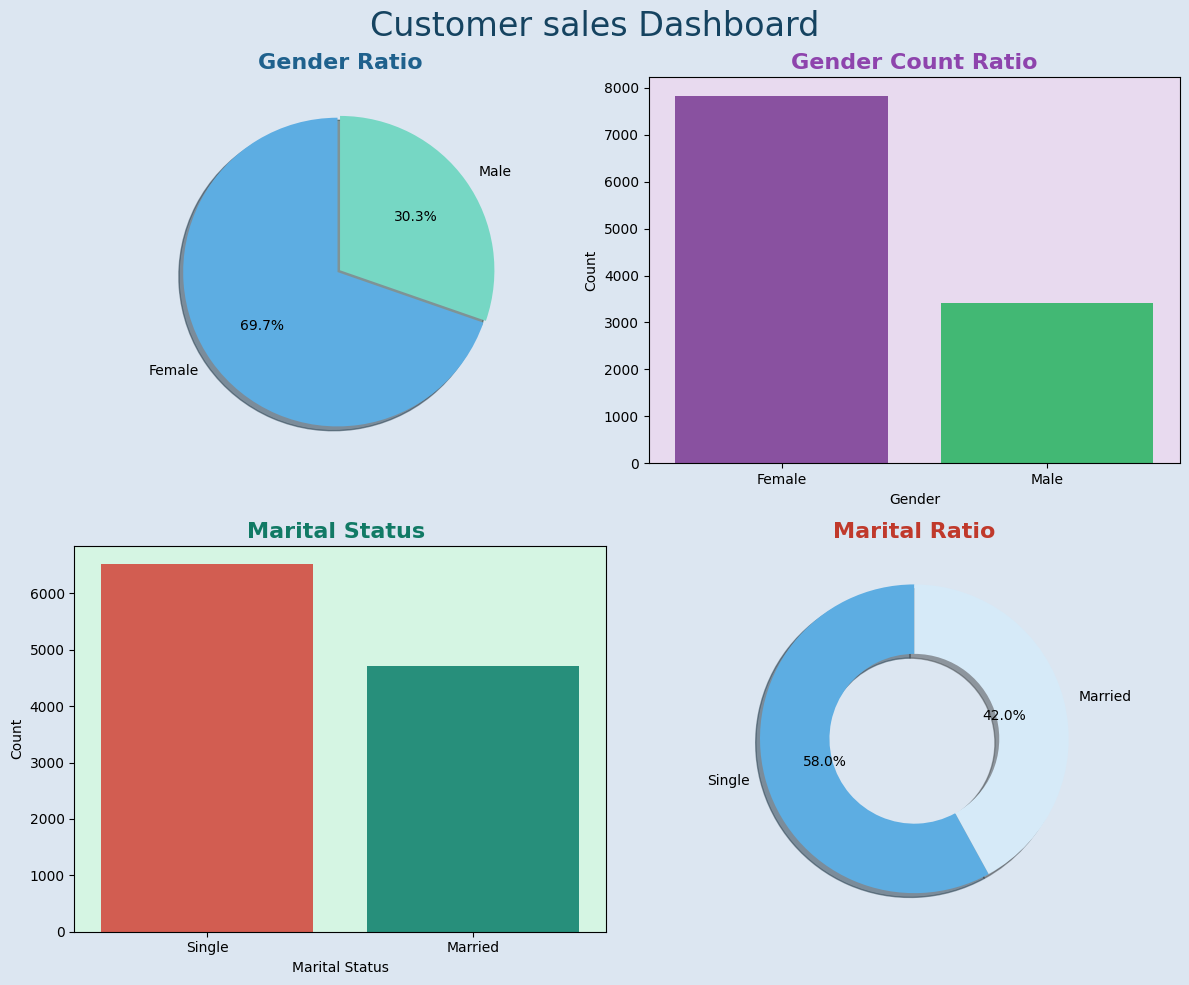

In [ ]:
plt.figure(figsize=(12,10), facecolor="#DCE6F1")
plt.suptitle("Customer sales Dashboard",fontsize=24,color="#154360")
# 1. Gender Ratio (Pie Chart)
plt.subplot(2,2,1)
gender = df["Gender"].value_counts()
plt.pie(gender,labels=gender.index,colors=["#5DADE2", "#76D7C4"],autopct="%1.1f%%",startangle=90,explode=(0.02,0),shadow=True)
plt.title("Gender Ratio",fontsize=16,fontweight="bold",color="#1F618D")
# 2. Gender Count (Count Plot)
plt.subplot(2,2,2)
sns.countplot(x="Gender",data=df,hue="Gender",palette=["#8E44AD", "#2ECC71"])
plt.gca().set_facecolor("#E8DAEF")
plt.title("Gender Count Ratio",fontsize=16,fontweight="bold",color="#8E44AD")
plt.xlabel("Gender")
plt.ylabel("Count")
# 3. Marital Count (Count Plot)
plt.subplot(2,2,3)
sns.countplot(x="Marital",data=df,hue="Marital",palette=["#E74C3C", "#16A085"])
plt.gca().set_facecolor("#D5F5E3")
plt.title("Marital Status ",fontsize=16,fontweight="bold",color="#117A65")
plt.xlabel("Marital Status")
plt.ylabel("Count")
# 4. Marital Ratio (Donut Chart)
plt.subplot(2,2,4)
marital = df["Marital"].value_counts()
plt.pie(marital,labels=marital.index,colors=["#5DADE2", "#D6EAF8"],autopct="%1.1f%%",startangle=90,shadow=True,wedgeprops={"width":0.45})
plt.title("Marital Ratio",fontsize=16,fontweight="bold",color="#C0392B")
plt.tight_layout()
plt.show()

#CONCLUSION
The Customer Sales Dashboard was developed to analyze customer demographic information and understand the distribution of customers based on gender and marital status. The main objective of this dashboard is to transform raw customer data into meaningful visual insights that help in better understanding customer characteristics and behavior patterns.

In this dashboard, multiple visualization techniques were implemented to represent customer information effectively. A Gender Ratio Pie Chart was created to analyze the percentage contribution of male and female customers, providing a clear view of the gender distribution within the customer base. A Gender Count Plot was used to display the actual number of customers belonging to each gender category, making it easier to compare customer volumes.

Similarly, Marital Status Analysis was performed to understand the distribution of married and unmarried customers. A Marital Status Count Plot was created to compare the number of customers in each category, while a Donut Chart was used to represent the percentage distribution of marital categories. These visualizations provide a better understanding of customer segments and their contribution to the overall customer base.

The dashboard was enhanced by applying customized colors, chart titles, background formatting, percentage labels, and proper layout arrangement to improve data readability and visual presentation. The combination of different chart types allows users to quickly interpret customer patterns and identify important demographic trends.

The use of Python libraries such as Pandas, Matplotlib, and Seaborn helped in data processing and creating effective visualizations. Pandas was used for data analysis and category-wise calculations, while Matplotlib and Seaborn were used for designing and presenting the charts in an attractive manner.

Overall, this Customer Sales Dashboard provides a simple and effective approach to analyze customer demographics. The insights generated from this dashboard can help businesses understand their customer base, improve customer segmentation, design targeted marketing strategies, and make informed data-driven decisions.


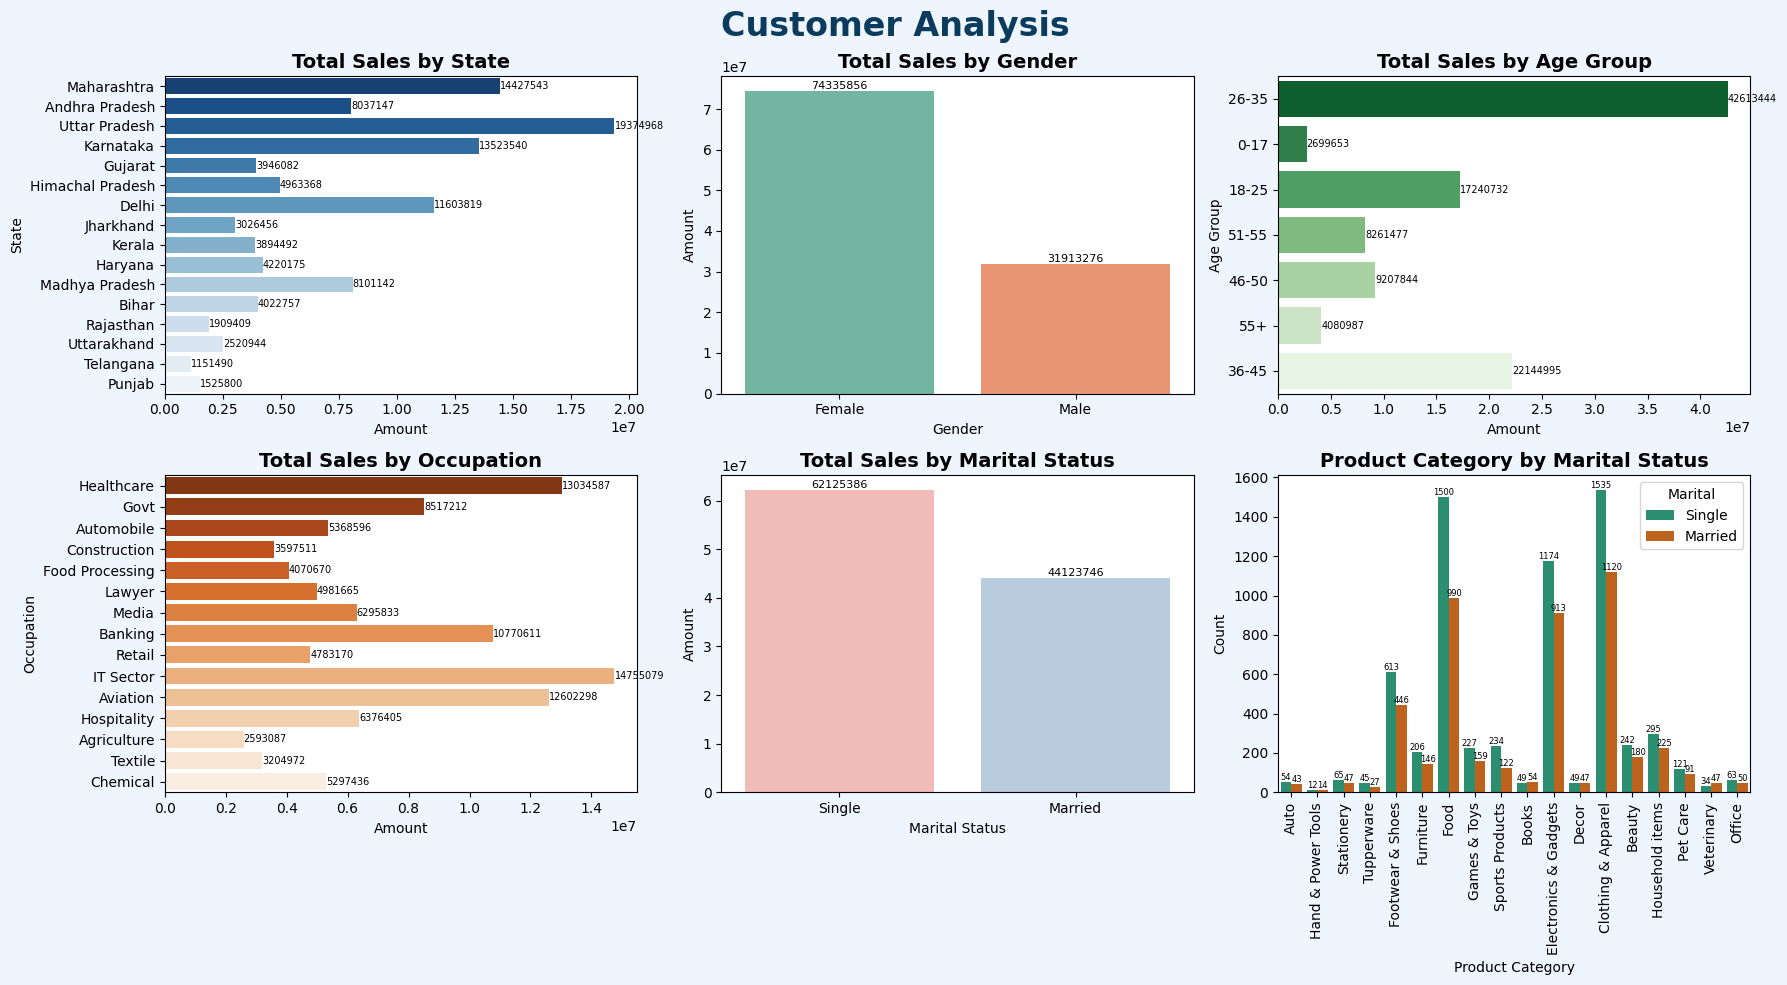

In [ ]:
plt.figure(figsize=(18,10), facecolor="#EEF5FF")
plt.suptitle("Customer Analysis",fontsize=24,fontweight="bold",color="#0B3C5D")
# Plot 1
plt.subplot(2,3,1)
ax = sns.barplot(x="Amount",y="State",data=df,estimator=sum,errorbar=None,hue="State",palette="Blues_r",legend=False)
plt.title("Total Sales by State", fontsize=14, fontweight="bold")
plt.xlabel("Amount")
plt.ylabel("State")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=7)
#Plot 2
plt.subplot(2,3,2)
ax = sns.barplot(x="Gender",y="Amount",data=df,estimator=sum,errorbar=None,hue="Gender",palette="Set2",legend=False)
plt.title("Total Sales by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Amount")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=8)
# Plot 3
plt.subplot(2,3,3)
ax = sns.barplot(x="Amount",y="Age Group",data=df,estimator=sum,errorbar=None,hue="Age Group",palette="Greens_r",legend=False)
plt.title("Total Sales by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Amount")
plt.ylabel("Age Group")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=7)
#  Plot 4
plt.subplot(2,3,4)
ax = sns.barplot(x="Amount",y="Occupation",data=df,estimator=sum,errorbar=None,hue="Occupation",palette="Oranges_r",legend=False)
plt.title("Total Sales by Occupation", fontsize=14, fontweight="bold")
plt.xlabel("Amount")
plt.ylabel("Occupation")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=7)
#  Plot 5
plt.subplot(2,3,5)
ax = sns.barplot(
x="Marital",y="Amount",data=df,estimator=sum,errorbar=None,hue="Marital",palette="Pastel1",legend=False)
plt.title("Total Sales by Marital Status", fontsize=14, fontweight="bold")
plt.xlabel("Marital Status")
plt.ylabel("Amount")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=8)
#  Plot 6
plt.subplot(2,3,6)
ax = sns.countplot(x="Product_Category",hue="Marital",data=df,palette="Dark2")
plt.title("Product Category by Marital Status", fontsize=14, fontweight="bold")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
for c in ax.containers:
    ax.bar_label(c, fontsize=6)
plt.tight_layout()
plt.show()

#CONCLUSION
The Customer Spending Analysis Dashboard was developed to analyze customer purchasing behavior and sales performance across different demographic categories. The dashboard provides a comprehensive view of sales distribution based on state, gender, age group, occupation, marital status, and product category.

The State-wise Sales Analysis helps in identifying the regions that contribute more towards total sales, allowing businesses to understand geographical sales performance. The Gender-wise Sales Analysis provides insights into the spending contribution of different gender groups and helps compare customer purchasing patterns.

The Age Group Analysis helps identify which age categories have higher spending behavior, while the Occupation-wise Sales Analysis provides an understanding of how customer professions influence purchasing patterns. The Marital Status Sales Analysis highlights differences in spending among various marital categories.

The final visualization analyzes Product Category based on Marital Status, which helps to understand the relationship between customer segments and their product preferences. This analysis provides insights into which product categories are more preferred by different customer groups.

The dashboard was created using bar chart visualizations with customized colors, proper labels, and formatting to make the insights clear and easy to interpret. Overall, this dashboard helps businesses understand customer behavior, identify high-performing segments, analyze sales trends, and make effective data-driven decisions for improving marketing strategies and increasing revenue.